# Capstone Modeling Notebook

This notebook rebuilds your county-level dataset and tests the first models for:

- **Obesity**
- **Diabetes**

using:

- **ACS 5-year** income + poverty
- **USDA Food Access Research Atlas**
- **CDC PLACES**

It produces:

- OLS regression summaries
- interaction models
- Random Forest comparisons
- RMSE, MAE, and test-set R²
- coefficient plots
- feature importance plots
- actual vs predicted plots

You can run this end-to-end in **Google Colab**.

## 0. Upload the two local files you already have

Before running the rest of the notebook, upload:

- `FoodAccessResearchAtlasData2019.xlsx`
- `PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260412.csv`

If your USDA filename has `(1)` at the end, that is fine. Just update the path in the file path cell below.

In [ ]:
# Optional upload step for Colab
# from google.colab import files
# uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

## 1. File paths

In [ ]:
USDA_PATH = "FoodAccessResearchAtlasData2019.xlsx"
PLACES_PATH = "PLACES__Local_Data_for_Better_Health,_County_Data,_2025_release_20260412.csv"

# If needed, uncomment and use this instead:
# USDA_PATH = "FoodAccessResearchAtlasData2019(1).xlsx"

print("USDA exists:", os.path.exists(USDA_PATH))
print("PLACES exists:", os.path.exists(PLACES_PATH))

USDA exists: True
PLACES exists: True


## 2. Pull ACS county data from the Census API

This gets:
- median household income
- poverty rate

In [ ]:
def get_census_json(url):
    response = requests.get(url, timeout=60)
    response.raise_for_status()
    raw = response.json()
    return pd.DataFrame(raw[1:], columns=raw[0])

income_url = (
    "https://api.census.gov/data/2022/acs/acs5"
    "?get=NAME,B19013_001E&for=county:*"
)

poverty_url = (
    "https://api.census.gov/data/2022/acs/acs5/subject"
    "?get=NAME,S1701_C03_001E&for=county:*"
)

income_df = get_census_json(income_url)
income_df["county_fips"] = income_df["state"] + income_df["county"]
income_df["median_income"] = pd.to_numeric(income_df["B19013_001E"], errors="coerce")
income_df = income_df[["county_fips", "NAME", "median_income"]]

poverty_df = get_census_json(poverty_url)
poverty_df["county_fips"] = poverty_df["state"] + poverty_df["county"]
poverty_df["poverty_rate"] = pd.to_numeric(poverty_df["S1701_C03_001E"], errors="coerce")
poverty_df = poverty_df[["county_fips", "poverty_rate"]]

acs_df = income_df.merge(poverty_df, on="county_fips", how="inner")
print("ACS shape:", acs_df.shape)
acs_df.head()

ACS shape: (3222, 4)


,county_fips,NAME,median_income,poverty_rate
0,01001,"Autauga County, Alabama",68315,11.4
1,01003,"Baldwin County, Alabama",71039,10.2
2,01005,"Barbour County, Alabama",39712,24.2
3,01007,"Bibb County, Alabama",50669,20.6
4,01009,"Blount County, Alabama",57440,14.2


## 3. Prepare USDA county food access data

We keep all counties and create a continuous variable:

- `low_access_share = low_access_population / total_population`

In [ ]:
usda = pd.read_excel(USDA_PATH, sheet_name="Food Access Research Atlas")
usda.columns = usda.columns.str.strip()

usda = usda[["CensusTract", "Pop2010", "LAPOP1_10"]].copy()
usda["county_fips"] = usda["CensusTract"].astype(str).str[:5]
usda["Pop2010"] = pd.to_numeric(usda["Pop2010"], errors="coerce")
usda["LAPOP1_10"] = pd.to_numeric(usda["LAPOP1_10"], errors="coerce")

usda_county = usda.groupby("county_fips", as_index=False).agg(
    total_population=("Pop2010", "sum"),
    low_access_population=("LAPOP1_10", "sum")
)

usda_county["low_access_share"] = usda_county["low_access_population"] / usda_county["total_population"]

usda_county = usda_county.replace([np.inf, -np.inf], np.nan)
usda_county = usda_county.dropna(subset=["low_access_share"])
usda_county = usda_county[
    (usda_county["low_access_share"] >= 0) &
    (usda_county["low_access_share"] <= 1)
].copy()

print("USDA county shape:", usda_county.shape)
usda_county.head()

USDA county shape: (3161, 4)


,county_fips,total_population,low_access_population,low_access_share
0,10001,162310,35057.108524,0.215989
1,10003,538479,153723.376143,0.285477
2,10005,197145,56335.053528,0.285754
3,10010,54571,18503.225506,0.339067
4,10030,182265,45789.046524,0.251222


## 4. Prepare CDC PLACES county health data

We extract:
- obesity
- diabetes

using `locationid` as county FIPS.

In [ ]:
places = pd.read_csv(PLACES_PATH, low_memory=False)

print(places.columns)

# Create county FIPS from the correct capitalized column
places["county_fips"] = places["LocationID"].astype(str).str.zfill(5)

# Use the correct capitalized text column
places["Short_Question_Text"] = places["Short_Question_Text"].astype(str).str.lower()

# Extract obesity
obesity = places[
    places["Short_Question_Text"].str.contains("obesity", na=False)
][["county_fips", "Data_Value"]].rename(columns={
    "Data_Value": "obesity"
})

# Extract diabetes
diabetes = places[
    places["Short_Question_Text"].str.contains("diabetes", na=False)
][["county_fips", "Data_Value"]].rename(columns={
    "Data_Value": "diabetes"
})

# Convert to numeric
obesity["obesity"] = pd.to_numeric(obesity["obesity"], errors="coerce")
diabetes["diabetes"] = pd.to_numeric(diabetes["diabetes"], errors="coerce")

# Merge
health = obesity.merge(diabetes, on="county_fips", how="inner").drop_duplicates()

print("Health shape:", health.shape)
health.head()

Index(['Year', 'StateAbbr', 'StateDesc', 'LocationName', 'DataSource',
       'Category', 'Measure', 'Data_Value_Unit', 'Data_Value_Type',
       'Data_Value', 'Data_Value_Footnote_Symbol', 'Data_Value_Footnote',
       'Low_Confidence_Limit', 'High_Confidence_Limit', 'TotalPopulation',
       'TotalPop18plus', 'LocationID', 'CategoryID', 'MeasureId',
       'DataValueTypeID', 'Short_Question_Text', 'Geolocation'],
      dtype='object')
Health shape: (11169, 3)


,county_fips,obesity,diabetes
0,08125,28.4,10.9
1,08125,28.4,9.2
2,13047,33.9,10.3
3,13047,33.9,12.5
4,13225,39.3,14.9


## 5. Merge all datasets

In [ ]:
merged = acs_df.merge(usda_county, on="county_fips", how="inner")
merged = merged.merge(health, on="county_fips", how="inner")

for col in ["median_income", "poverty_rate", "low_access_share", "obesity", "diabetes"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")

merged = merged.dropna(subset=["median_income", "poverty_rate", "low_access_share", "obesity", "diabetes"])

merged = merged[
    (merged["median_income"] > 0) &
    (merged["median_income"] < 200000) &
    (merged["poverty_rate"] >= 0) &
    (merged["poverty_rate"] <= 60) &
    (merged["low_access_share"] >= 0) &
    (merged["low_access_share"] <= 1) &
    (merged["obesity"] >= 0) &
    (merged["obesity"] <= 100) &
    (merged["diabetes"] >= 0) &
    (merged["diabetes"] <= 100)
].copy()

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (9892, 9)


,county_fips,NAME,median_income,poverty_rate,total_population,low_access_population,low_access_share,obesity,diabetes
0,10001,"Kent County, Delaware",69278,12.3,162310,35057.108524,0.215989,43.9,12.4
1,10001,"Kent County, Delaware",69278,12.3,162310,35057.108524,0.215989,43.9,14.3
2,10001,"Kent County, Delaware",69278,12.3,162310,35057.108524,0.215989,43.5,12.4
3,10001,"Kent County, Delaware",69278,12.3,162310,35057.108524,0.215989,43.5,14.3
4,10003,"New Castle County, Delaware",85309,10.5,538479,153723.376143,0.285477,33.4,12.2


## 6. Modeling helpers

In [ ]:
def fit_ols(df, target, features, test_size=0.2, random_state=42):
    X = df[features].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    X_train_sm = sm.add_constant(X_train)
    X_test_sm = sm.add_constant(X_test)

    model = sm.OLS(y_train, X_train_sm).fit()
    y_pred = model.predict(X_test_sm)

    coef_table = pd.DataFrame({
        "variable": model.params.index,
        "coefficient": model.params.values,
        "p_value": model.pvalues.values
    })

    metrics = {
        "target": target,
        "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "mae": float(mean_absolute_error(y_test, y_pred)),
        "r2_test": float(r2_score(y_test, y_pred)),
        "adj_r2_train": float(model.rsquared_adj),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test))
    }

    preds = pd.DataFrame({"actual": y_test, "predicted": y_pred})

    return model, coef_table, metrics, preds


def fit_rf(df, target, features, test_size=0.2, random_state=42):
    X = df[features].copy()
    y = df[target].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    rf = RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=2,
        random_state=random_state
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    importance = pd.DataFrame({
        "variable": features,
        "importance": rf.feature_importances_
    }).sort_values("importance", ascending=False)

    metrics = {
        "target": target,
        "rmse": float(np.sqrt(mean_squared_error(y_test, y_pred))),
        "mae": float(mean_absolute_error(y_test, y_pred)),
        "r2_test": float(r2_score(y_test, y_pred)),
        "n_train": int(len(X_train)),
        "n_test": int(len(X_test))
    }

    preds = pd.DataFrame({"actual": y_test, "predicted": y_pred})

    return rf, importance, metrics, preds


plt.style.use("seaborn-v0_8")

def plot_actual_vs_predicted(preds_df, title, filename):
    plt.figure()

    plt.scatter(
        preds_df["actual"],
        preds_df["predicted"],
        alpha=0.5,
        color="#1f77b4"   # blue
    )

    low = min(preds_df["actual"].min(), preds_df["predicted"].min())
    high = max(preds_df["actual"].max(), preds_df["predicted"].max())

    plt.plot([low, high], [low, high],
             linestyle="--",
             color="#d62728",  # red
             linewidth=2)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


def plot_coefficients(coef_df, title, filename):
    tmp = coef_df[coef_df["variable"] != "const"].copy()

    plt.figure()
    plt.bar(
        tmp["variable"],
        tmp["coefficient"],
        color="#2ca02c"   # green
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Coefficient")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


def plot_importance(importance_df, title, filename):
    plt.figure()

    plt.bar(
        importance_df["variable"],
        importance_df["importance"],
        color="#9467bd"   # purple
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

## 7. Baseline OLS models

In [ ]:
baseline_features = ["low_access_share", "median_income", "poverty_rate"]

ols_obesity, coef_obesity, metrics_obesity, preds_obesity = fit_ols(
    merged, "obesity", baseline_features
)
print("Obesity OLS metrics:", metrics_obesity)
display(coef_obesity)
print(ols_obesity.summary())

Obesity OLS metrics: {'target': 'obesity', 'rmse': 3.4897244499282754, 'mae': 2.7195118758553756, 'r2_test': 0.34813554113941025, 'adj_r2_train': 0.3579682391754161, 'n_train': 7913, 'n_test': 1979}


,variable,coefficient,p_value
0,const,44.670622,0.000000e+00
1,low_access_share,-1.549277,6.356684e-13
2,median_income,-0.000125,1.955833e-269
3,poverty_rate,0.105237,4.087781e-29


                            OLS Regression Results                            
Dep. Variable:                obesity   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.358
Method:                 Least Squares   F-statistic:                     1471.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:14:03   Log-Likelihood:                -20971.
No. Observations:                7913   AIC:                         4.195e+04
Df Residuals:                    7909   BIC:                         4.198e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               44.6706      0.333  

In [ ]:
ols_diabetes, coef_diabetes, metrics_diabetes, preds_diabetes = fit_ols(
    merged, "diabetes", baseline_features
)
print("Diabetes OLS metrics:", metrics_diabetes)
display(coef_diabetes)
print(ols_diabetes.summary())

Diabetes OLS metrics: {'target': 'diabetes', 'rmse': 2.0271824933178344, 'mae': 1.6574375679899784, 'r2_test': 0.4721367149050958, 'adj_r2_train': 0.46448446604928273, 'n_train': 7913, 'n_test': 1979}


,variable,coefficient,p_value
0,const,11.633097,0.000000e+00
1,low_access_share,-0.327645,1.043954e-02
2,median_income,-0.000038,1.332407e-75
3,poverty_rate,0.233945,0.000000e+00


                            OLS Regression Results                            
Dep. Variable:               diabetes   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     2289.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:14:03   Log-Likelihood:                -16860.
No. Observations:                7913   AIC:                         3.373e+04
Df Residuals:                    7909   BIC:                         3.376e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               11.6331      0.198  

## 8. Interaction OLS models

These test whether food access behaves differently across income levels.

In [ ]:
merged["fa_x_income"] = merged["low_access_share"] * merged["median_income"]
interaction_features = ["low_access_share", "median_income", "poverty_rate", "fa_x_income"]

ols_obesity_int, coef_obesity_int, metrics_obesity_int, preds_obesity_int = fit_ols(
    merged, "obesity", interaction_features
)
print("Obesity interaction metrics:", metrics_obesity_int)
display(coef_obesity_int)
print(ols_obesity_int.summary())

Obesity interaction metrics: {'target': 'obesity', 'rmse': 3.4775404148127933, 'mae': 2.7137055786392206, 'r2_test': 0.35267943829596216, 'adj_r2_train': 0.3609063957659352, 'n_train': 7913, 'n_test': 1979}


,variable,coefficient,p_value
0,const,45.994925,0.000000e+00
1,low_access_share,-6.604414,1.210032e-14
2,median_income,-0.000146,3.594074e-186
3,poverty_rate,0.104413,8.298820e-29
4,fa_x_income,0.000082,1.028362e-09


                            OLS Regression Results                            
Dep. Variable:                obesity   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     1118.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:14:03   Log-Likelihood:                -20953.
No. Observations:                7913   AIC:                         4.192e+04
Df Residuals:                    7908   BIC:                         4.195e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               45.9949      0.397  

In [ ]:
ols_diabetes_int, coef_diabetes_int, metrics_diabetes_int, preds_diabetes_int = fit_ols(
    merged, "diabetes", interaction_features
)
print("Diabetes interaction metrics:", metrics_diabetes_int)
display(coef_diabetes_int)
print(ols_diabetes_int.summary())

Diabetes interaction metrics: {'target': 'diabetes', 'rmse': 2.0243952671625163, 'mae': 1.6548368714574682, 'r2_test': 0.47358726305527654, 'adj_r2_train': 0.4651055438966871, 'n_train': 7913, 'n_test': 1979}


,variable,coefficient,p_value
0,const,12.045056,0.000000e+00
1,low_access_share,-1.900177,1.909393e-04
2,median_income,-0.000045,6.235439e-52
3,poverty_rate,0.233689,0.000000e+00
4,fa_x_income,0.000026,1.422711e-03


                            OLS Regression Results                            
Dep. Variable:               diabetes   R-squared:                       0.465
Model:                            OLS   Adj. R-squared:                  0.465
Method:                 Least Squares   F-statistic:                     1721.
Date:                Mon, 20 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:14:03   Log-Likelihood:                -16855.
No. Observations:                7913   AIC:                         3.372e+04
Df Residuals:                    7908   BIC:                         3.376e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               12.0451      0.236  

## 9. Random Forest comparison

In [ ]:
rf_obesity, imp_obesity, rf_metrics_obesity, rf_preds_obesity = fit_rf(
    merged, "obesity", baseline_features
)
print("Obesity RF metrics:", rf_metrics_obesity)
display(imp_obesity)

Obesity RF metrics: {'target': 'obesity', 'rmse': 1.2139417721888568, 'mae': 0.8144447240727769, 'r2_test': 0.9211193024794713, 'n_train': 7913, 'n_test': 1979}


,variable,importance
1,median_income,0.580235
0,low_access_share,0.212837
2,poverty_rate,0.206928


In [ ]:
rf_diabetes, imp_diabetes, rf_metrics_diabetes, rf_preds_diabetes = fit_rf(
    merged, "diabetes", baseline_features
)
print("Diabetes RF metrics:", rf_metrics_diabetes)
display(imp_diabetes)

Diabetes RF metrics: {'target': 'diabetes', 'rmse': 1.852563762707696, 'mae': 1.6213385618310052, 'r2_test': 0.5591588855007322, 'n_train': 7913, 'n_test': 1979}


,variable,importance
1,median_income,0.49877
2,poverty_rate,0.36240
0,low_access_share,0.13883


## 10. Model result figures

These are the best new figures for the Results section.

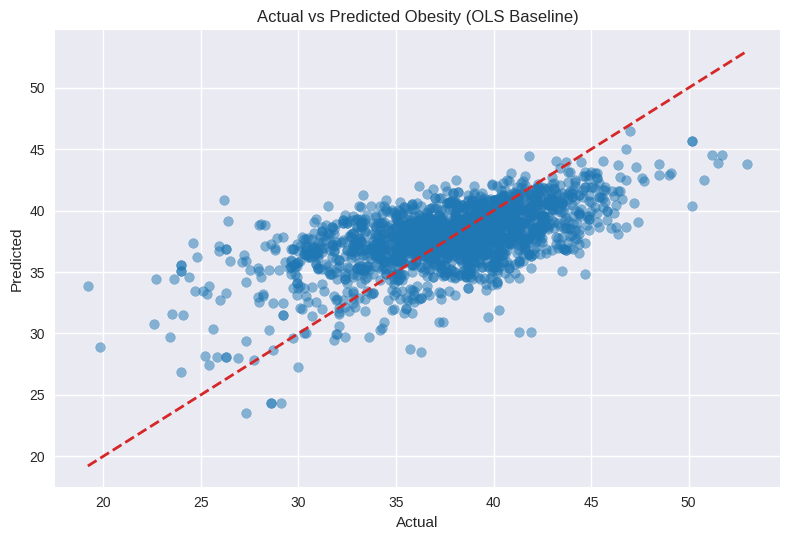

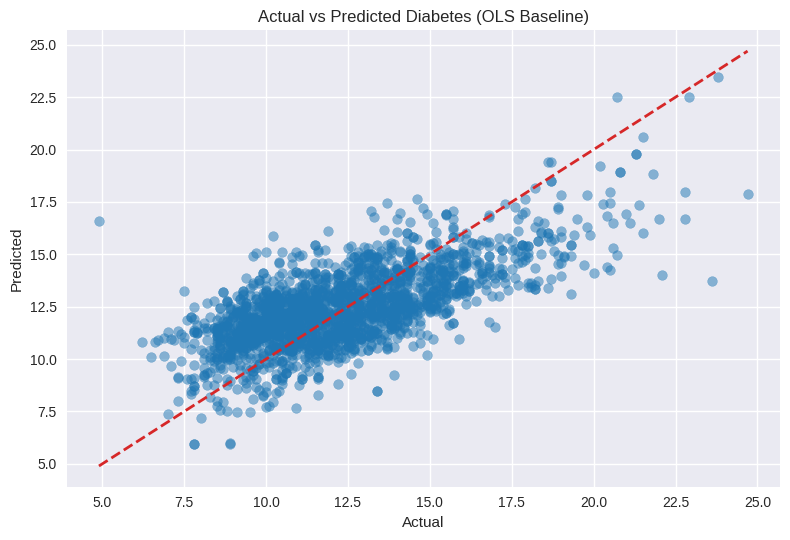

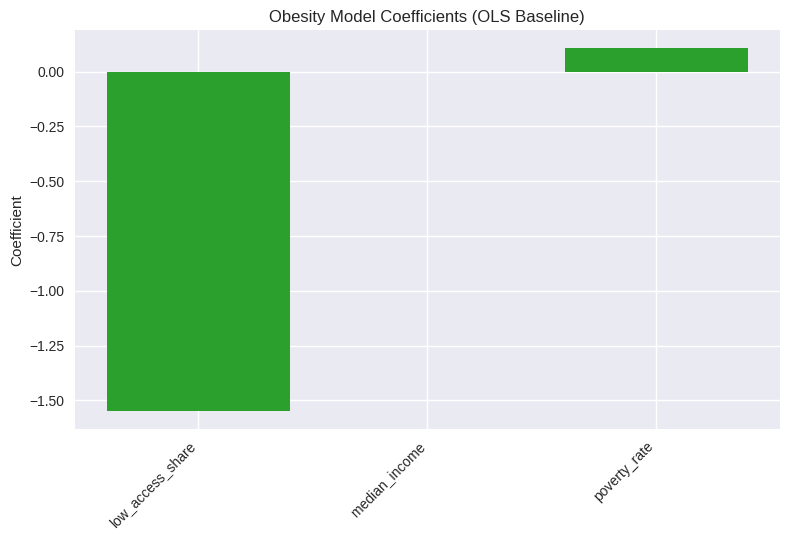

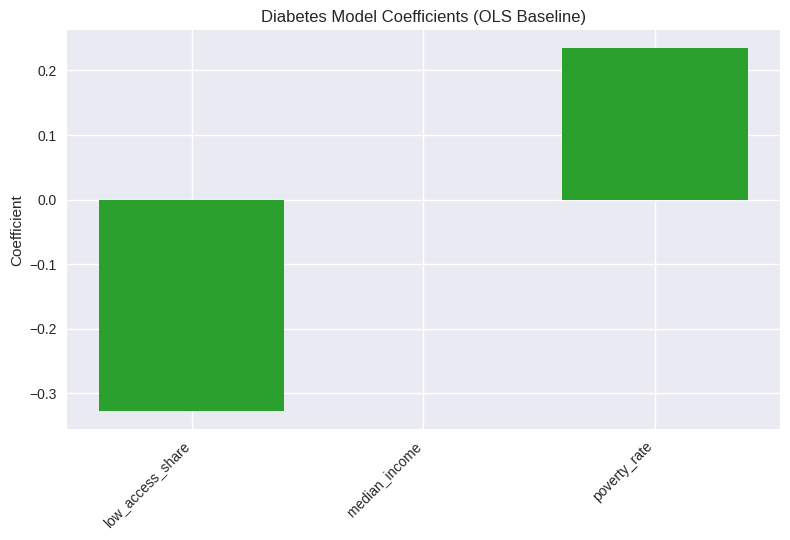

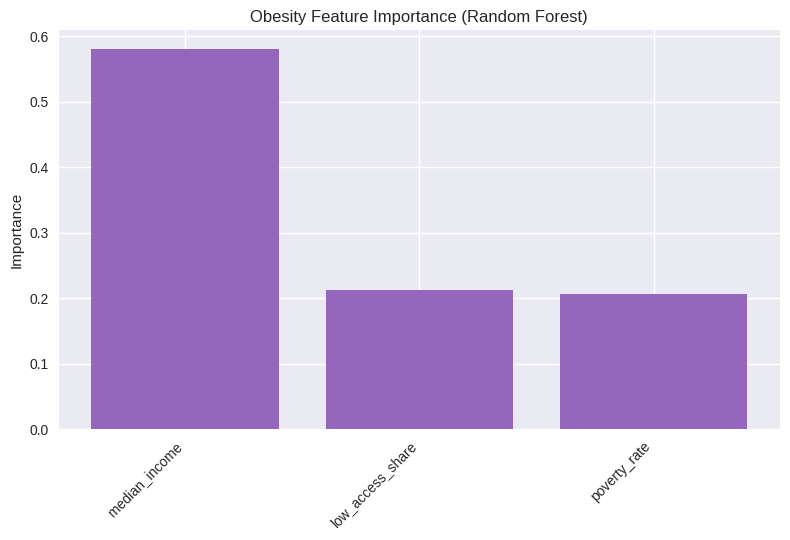

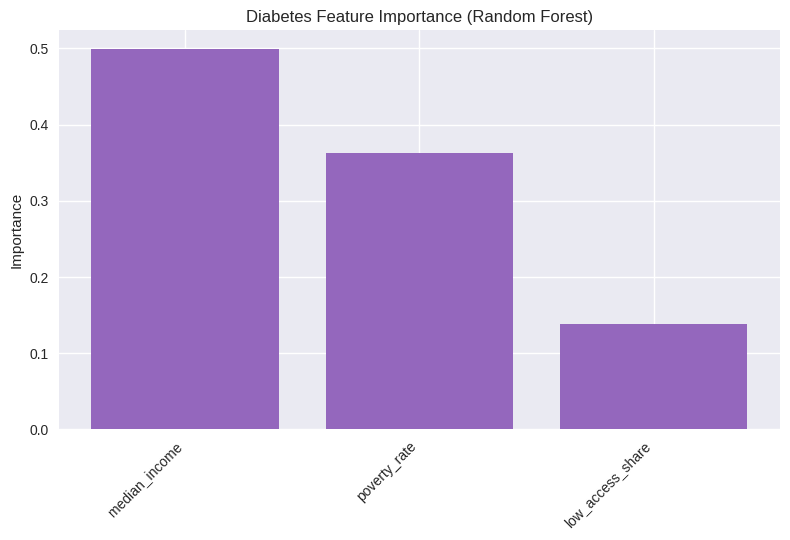

In [ ]:
plot_actual_vs_predicted(
    preds_obesity,
    "Actual vs Predicted Obesity (OLS Baseline)",
    "model_actual_vs_predicted_obesity_ols.png"
)

plot_actual_vs_predicted(
    preds_diabetes,
    "Actual vs Predicted Diabetes (OLS Baseline)",
    "model_actual_vs_predicted_diabetes_ols.png"
)

plot_coefficients(
    coef_obesity,
    "Obesity Model Coefficients (OLS Baseline)",
    "model_coefficients_obesity_ols.png"
)

plot_coefficients(
    coef_diabetes,
    "Diabetes Model Coefficients (OLS Baseline)",
    "model_coefficients_diabetes_ols.png"
)

plot_importance(
    imp_obesity,
    "Obesity Feature Importance (Random Forest)",
    "model_feature_importance_obesity_rf.png"
)

plot_importance(
    imp_diabetes,
    "Diabetes Feature Importance (Random Forest)",
    "model_feature_importance_diabetes_rf.png"
)

## 11. Compare models in one summary table

In [ ]:
results_table = pd.DataFrame([
    {"model": "OLS Baseline", **metrics_obesity},
    {"model": "OLS Interaction", **metrics_obesity_int},
    {"model": "RF Baseline", **rf_metrics_obesity},
    {"model": "OLS Baseline", **metrics_diabetes},
    {"model": "OLS Interaction", **metrics_diabetes_int},
    {"model": "RF Baseline", **rf_metrics_diabetes},
])

display(results_table)
results_table.to_csv("model_results_summary.csv", index=False)

,model,target,rmse,mae,r2_test,adj_r2_train,n_train,n_test
0,OLS Baseline,obesity,3.489724,2.719512,0.348136,0.357968,7913,1979
1,OLS Interaction,obesity,3.477540,2.713706,0.352679,0.360906,7913,1979
2,RF Baseline,obesity,1.213942,0.814445,0.921119,NaN,7913,1979
3,OLS Baseline,diabetes,2.027182,1.657438,0.472137,0.464484,7913,1979
4,OLS Interaction,diabetes,2.024395,1.654837,0.473587,0.465106,7913,1979
5,RF Baseline,diabetes,1.852564,1.621339,0.559159,NaN,7913,1979


## 12. Download outputs

In [ ]:
# Uncomment in Colab if you want one-click downloads
from google.colab import files
for f in [
    "model_results_summary.csv",
    "model_actual_vs_predicted_obesity_ols.png",
    "model_actual_vs_predicted_diabetes_ols.png",
    "model_coefficients_obesity_ols.png",
    "model_coefficients_diabetes_ols.png",
    "model_feature_importance_obesity_rf.png",
    "model_feature_importance_diabetes_rf.png",
]:
    if os.path.exists(f):
        files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. What to use in the paper

Once this runs, the strongest new figures for your **Results, Implications, and Challenges** file are usually:

1. `model_coefficients_obesity_ols.png`
2. `model_coefficients_diabetes_ols.png`
3. `model_feature_importance_obesity_rf.png`
4. `model_feature_importance_diabetes_rf.png`

And the most important table is:

- `model_results_summary.csv`

Use the OLS summaries to report:
- coefficient signs
- p-values
- whether food access stays weak after controls
- whether income and poverty dominate